# Чувствительность к коэффициенту заражения
§6.1.4, стр. 200–202: ровно 15 значений β и заданная сетка наблюдений .5.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("SIRPetri.jl"))
using .SIRPetri
include(srcdir("experiment_support.jl"))

animate_sir

## Сканирование при γ=.1

In [2]:
β_range = 0.1:0.05:0.8
γ_fixed, tmax = 0.1, 100.0
df_scan = DataFrame(β=Float64[], peak_I=Float64[], final_R=Float64[])
df_refined = DataFrame(β=Float64[], peak_I=Float64[], peak_time=Float64[], analytic=Float64[])
for β in β_range
    net, u0, _ = build_sir_network(β, γ_fixed)
    df = simulate_deterministic(net, u0, (0.0, tmax); saveat=0.5, rates=[β, γ_fixed])
    push!(df_scan, (β, maximum(df.I), df.R[end]))
    peak = refined_peak(net, u0, (0.0, tmax); rates=[β, γ_fixed])
    push!(df_refined, (β, peak.peak, peak.time, peak.analytic))
end
save_table("sir_scan.csv", df_scan)
save_table("sir_scan_refined.csv", df_refined)
df_scan

Row,β,peak_I,final_R
,Float64,Float64,Float64
1,0.1,955.626,999.954
2,0.15,954.157,999.954
3,0.2,953.424,999.954
4,0.25,952.984,999.955
5,0.3,952.691,999.955
6,0.35,952.482,999.955
7,0.4,952.326,999.955
8,0.45,952.204,999.955
9,0.5,952.106,999.955


## Обязательные показатели на заданной сетке

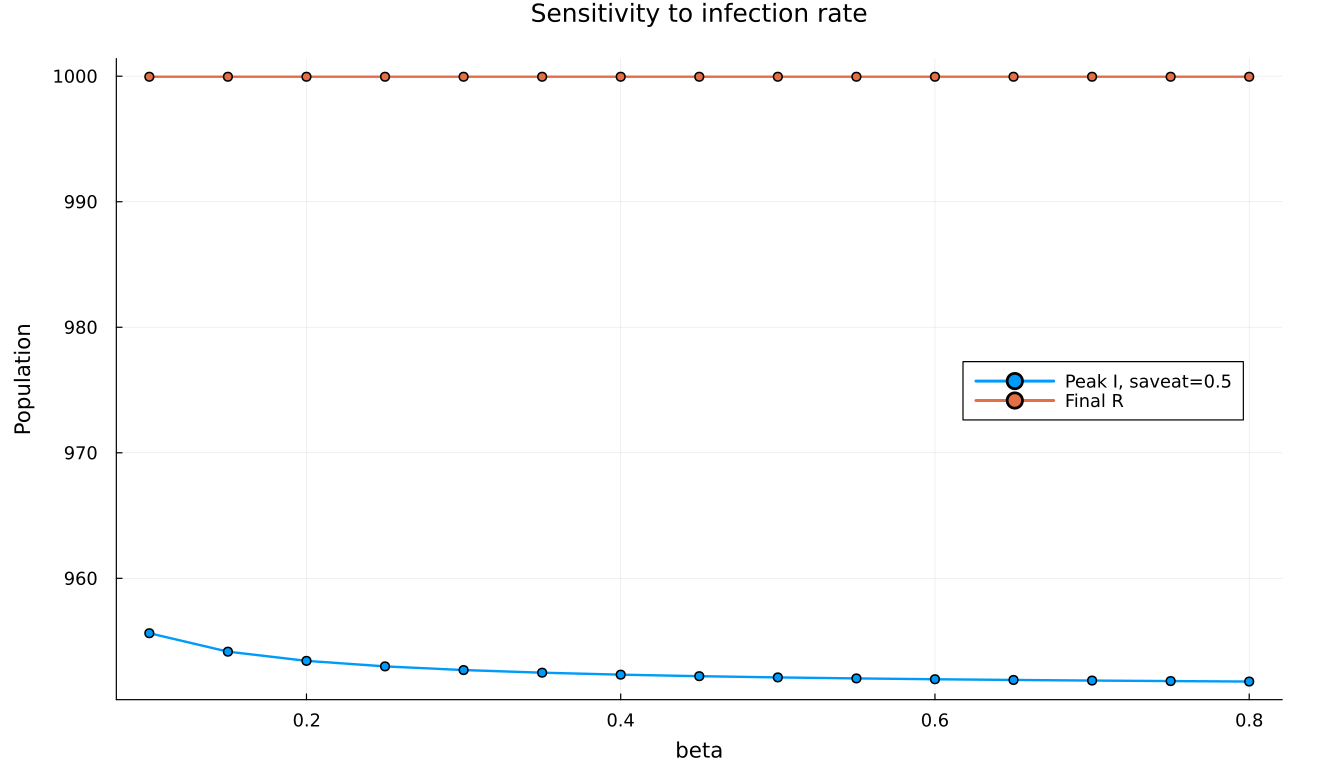

In [3]:
p = plot(df_scan.β, [df_scan.peak_I df_scan.final_R];
    label=["Peak I, saveat=0.5" "Final R"], marker=:circle,
    xlabel="beta", ylabel="Population", title="Sensitivity to infection rate")
savefig(p, imagepath("05-plot.png"))
display(p)

## Уточнённый пик не равен максимуму дискретных отсчётов

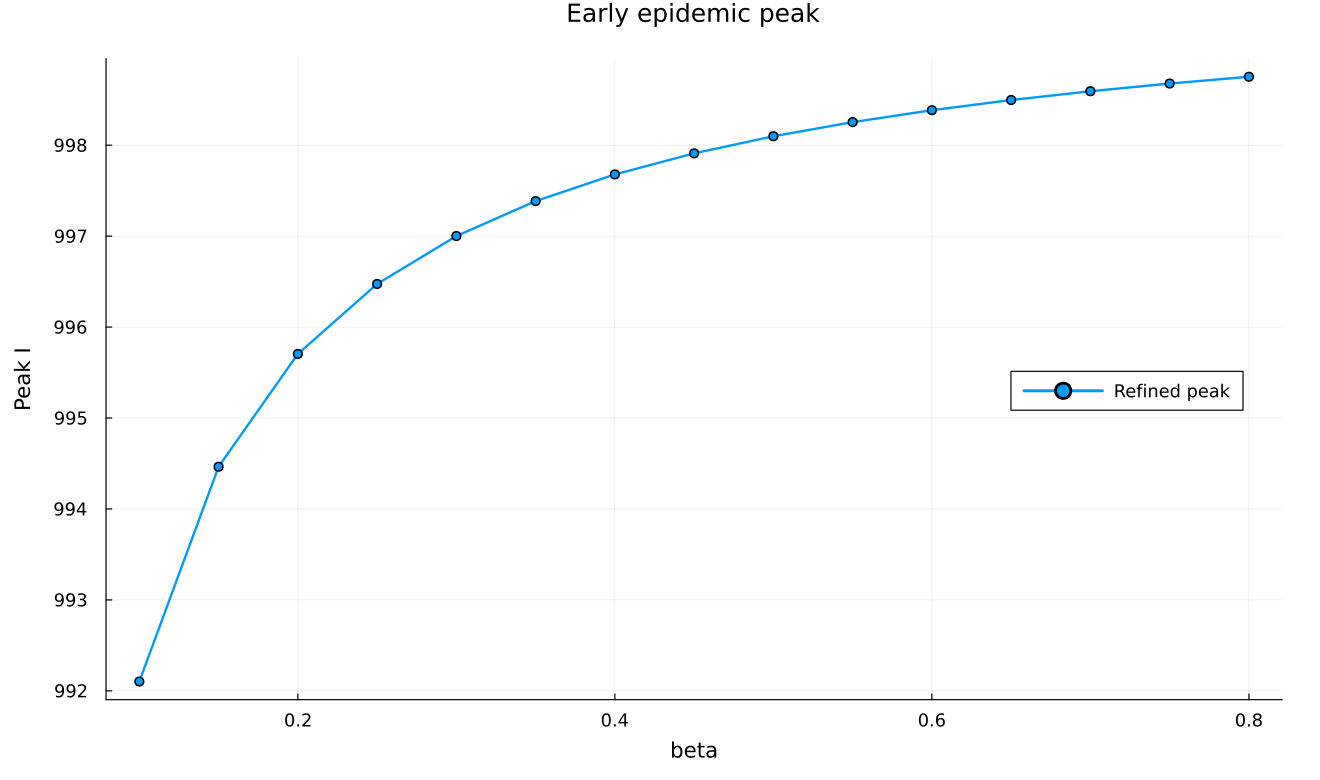

Row,β,peak_I,peak_time,analytic
,Float64,Float64,Float64,Float64
1,0.1,992.102,0.11532,992.102
2,0.15,994.465,0.0795309,994.465
3,0.2,995.705,0.0610653,995.705
4,0.25,996.474,0.0497339,996.474
5,0.3,997.001,0.0420463,997.001
6,0.35,997.386,0.0364761,997.386
7,0.4,997.679,0.0322476,997.679
8,0.45,997.911,0.0289244,997.911
9,0.5,998.099,0.0262412,998.099


In [4]:
p_peak = plot(df_refined.β, df_refined.peak_I; marker=:circle,
    label="Refined peak", xlabel="beta", ylabel="Peak I", title="Early epidemic peak")
savefig(p_peak, imagepath("06-plot.png"))
display(p_peak)
df_refined